# Soft Computing Assignment – 2

# Motivation & Idea
Accoring to Jamali et al [5], there aren't many algorithms taking inspiration from plant behaviour. Rather a lot of Algorithms seem seek inspiration from the animal
In a number of plant species (e.g. cereals), the primary root system will dominate the early growth stages while the adventitious root system will dominate in older plants. In the latter case, the location and dynamic of the nodal root emissions are of prime importance for the general structure of the root system as has been demonstrated using cereals [1]

### References
- [1]: Hodge et al(2009): Plant root growth, architecture and function
- [3]: Dietrich(2018): Hydrotropism: how roots search for water
- [5]: Jamali et al(2025): A Systematic Review of Bio-Inspired Metaheuristic Optimization Algorithms: The Untapped Potential of Plant-Based Approaches 

<img src="https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fwww.frontiersin.org%2Ffiles%2FArticles%2F1120583%2Ffpls-14-1120583-HTML-r1%2Fimage_m%2Ffpls-14-1120583-g001.jpg&f=1&nofb=1&ipt=9aa9c5732380295e1a45d7c84d4d9e22609925c30afd312e70ed91400f0747ed" alt="Description" width="300" height="200">

## Algorithm

#### Agent Representation
Each agent = a root tip (a point in the search space).
Each agent has:

A position (coordinates in the search space).
A direction (normalized vector representing growth).
A history (path taken, for memory).
A fitness (resource availability or objective function value).
A status (active, dead, or split).


#### Growth/Death Cycle
**Agents die if:**
They reach a resource (success).
They hit a constraint (e.g., boundary, maximum depth).
They fail to find resources for too long (energy depletion).


**Splitting:**
When an agent finds a rich resource, it splits into multiple agents to explore the neighborhood (local search).
Splitting requires energy (step cost)

#### Movement Physics

**Gravitropism:**
Represented as a constraint (e.g., a vector pulling the agent toward the objective function’s "bottom").
Can be modeled as a penalty or a directional bias.

**Hydrotropism:**
Represented as a gradient (e.g., the agent moves toward higher resource availability).
Can be modeled as a force or a probability distribution.

**Combined Movement:**
The agent’s direction is a weighted sum of:
Gravitropism (toward objective).
Hydrotropism (toward resources).
Randomness (exploration).


#### Communication Topology
Shared environment: All agents "see" the same resource map (like pheromones).
Path sharing: Agents leave "trails" (e.g., resource traces) that other agents can follow.
Ancestry: Agents inherit traits from their "parent" root (e.g., direction bias).

#### Memory
Path memory: Agents remember their path to avoid revisiting low-resource areas. (Visited Set)
Best path: Agents can "remember" the best path found so far (like a global best in PSO).


Algorithm : 

```txt
Each root agent has:

position
energy
growth direction
personal best

At each iteration:

Each root senses:
local fitness-derived moisture gradient
gravity bias
local competition repulsion
random exploratory perturbation
It grows one step in the normalized weighted sum direction.
It evaluates the new position:
if fitness improved, energy increases
otherwise energy decreases by growth cost
If energy exceeds a threshold:
the root branches into children
children inherit partial energy and slightly diverging directions
If energy falls to zero:
the root dies
Roots update the shared moisture field:
promising regions become wetter
occupied regions may be depleted
```

---


### Mathematical Formalization




### Pseudo Code

```py
Initialize dynamic moisture field M
Initialize a few root agents at random positions
For each root:
    evaluate objective
    set personal best
    set initial energy

while at least one root is alive:
    new_roots = []

    for each alive root:
        sense local moisture bias
        sense repulsion from nearby roots
        sample random exploration direction
        combine influences into growth direction

        propose new position
        apply boundary handling
        evaluate objective at new position

        improvement = old_fitness - new_fitness
        energy += reward_from(improvement) - movement_cost

        if improvement > 0:
            deposit moisture around new position

        deplete moisture at current position
        update personal best

        if energy <= 0:
            mark dead
        elif energy >= split_threshold and population < max_root_count:
            create child roots in nearby perturbed directions
            share energy between parent and children
            append children to new_roots

    add new_roots to population

return best personal best among all roots
```

# Benchmarking & Analysis

In this section the algorithm is tested on Rastrigin, Ackley, Schwefel and Rosenbrock function.

The result shows that the algorithm demonstrably works, shows meaningful convergence on multiple standard benchmarks, and performs especially well on Ackley and Rosenbrock, but still struggles on highly multimodal landscapes like Rastrigin and to a lesser extent Schwefel.

In [8]:
from RootAlgorithm import PlantAlgorithm
import numpy as np
import matplotlib.pyplot as plt


Rastrigin benchmark
-------------------
Step size    : 0.512
Best fitness : 19.346060318616274
Best position: [2.97555161 0.96423807 2.94990236]

Ackley benchmark
----------------
Step size    : 3.2768
Best fitness : 1.2744436778051491
Best position: [-0.02223414  0.22449489 -0.07064888]

Schwefel benchmark
------------------
Step size    : 50.0
Best fitness : 315.10356578586334
Best position: [-119.82458307  425.06044786  431.39076701]

Rosenbrock benchmark
--------------------
Step size    : 0.2048
Best fitness : 0.05427855220705797
Best position: [0.97793861 0.97813868 0.96443638]


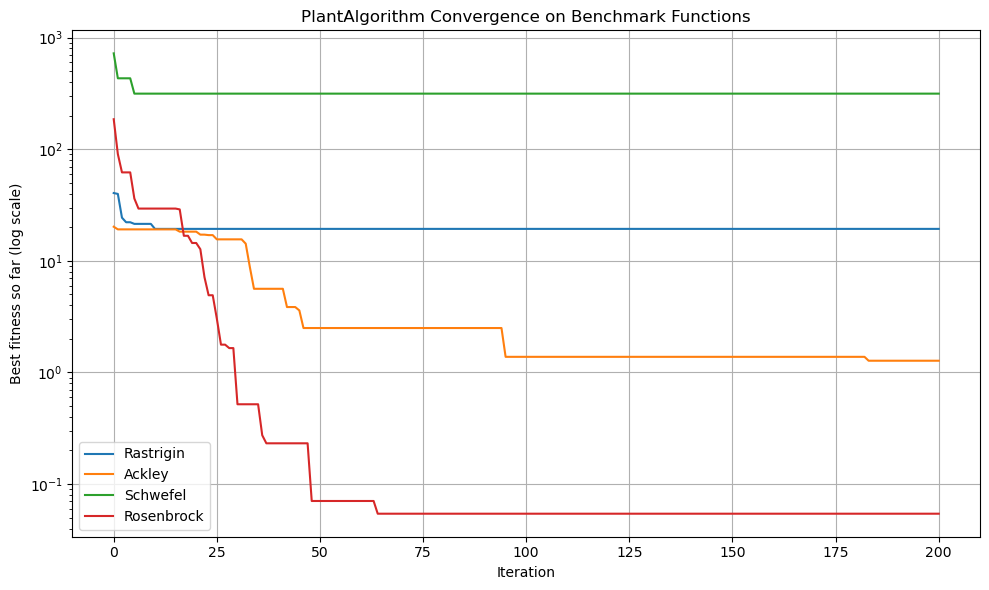

In [9]:
if __name__ == "__main__":
    def rastrigin(x: np.ndarray) -> float:
        x = np.asarray(x, dtype=float)
        n = x.size
        return float(10.0 * n + np.sum(x**2 - 10.0 * np.cos(2.0 * np.pi * x)))

    def ackley(x: np.ndarray) -> float:
        x = np.asarray(x, dtype=float)
        n = x.size
        sum_sq = np.sum(x**2)
        sum_cos = np.sum(np.cos(2.0 * np.pi * x))
        term1 = -20.0 * np.exp(-0.2 * np.sqrt(sum_sq / n))
        term2 = -np.exp(sum_cos / n)
        return float(term1 + term2 + 20.0 + np.e)

    def schwefel(x: np.ndarray) -> float:
        x = np.asarray(x, dtype=float)
        n = x.size
        return float(418.9829 * n - np.sum(x * np.sin(np.sqrt(np.abs(x)))))

    def rosenbrock(x: np.ndarray) -> float:
        x = np.asarray(x, dtype=float)
        return float(np.sum(100.0 * (x[1:] - x[:-1] ** 2) ** 2 + (1.0 - x[:-1]) ** 2))

    def compute_step_size(bounds, scale=0.05):
        bounds_arr = np.asarray(bounds, dtype=float)
        widths = bounds_arr[:, 1] - bounds_arr[:, 0]
        return scale * float(np.mean(widths))

    def benchmark_functions() -> None:
        dimension = 3

        test_cases = [
            ("Rastrigin", rastrigin, [(-5.12, 5.12)] * dimension),
            ("Ackley", ackley, [(-32.768, 32.768)] * dimension),
            ("Schwefel", schwefel, [(-500.0, 500.0)] * dimension),
            ("Rosenbrock", rosenbrock, [(-2.048, 2.048)] * dimension),
        ]

        histories = {}

        for name, func, bounds in test_cases:
            step_size = compute_step_size(bounds, scale=0.05)

            optimizer = PlantAlgorithm(
                objective_function=func,
                bounds=bounds,
                max_root_count=80,
                initial_energy=6.0,
                step_size=step_size,
                step_cost=0.03,
                splitting_threshold=8.0,
                max_children=1,
                alpha=12.0,
                deposit_scale=2.5,
                depletion_scale=0.02,
                weights=(1.8, 0.0, 0.4, 0.3),
                repulsion_radius=1.8,
                gravity_vector=np.zeros(dimension),
                personal_best_weight=0.8,
                moisture_sigma=0.4,
                moisture_base=0.01,
                evaporation_rate=0.005,
                split_ratio=0.6,
                child_offset=0.5 * step_size,
                initial_root_count=12,
                seed=42,
            )

            best_position, best_fitness = optimizer.run(max_iterations=200)
            histories[name] = optimizer.history

            print(f"\n{name} benchmark")
            print("-" * (len(name) + 10))
            print("Step size    :", step_size)
            print("Best fitness :", best_fitness)
            print("Best position:", best_position)

        plt.figure(figsize=(10, 6))

        for name, history in histories.items():
            plt.plot(history, label=name)

        plt.yscale("log")
        plt.xlabel("Iteration")
        plt.ylabel("Best fitness so far (log scale)")
        plt.title("PlantAlgorithm Convergence on Benchmark Functions")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig("plant_benchmark.png", dpi=200)
        plt.show()

    benchmark_functions()

# PSO and ABC

Comparing the algorithm against ABC and PSO we see that


Rastrigin benchmark
-------------------
Step size    : 0.512
Best fitness : 0.0
Best position: [-1.18699624e-09 -1.60206391e-09  2.67836800e-09]

Ackley benchmark
----------------
Step size    : 3.2768
Best fitness : 3.9968028886505635e-15
Best position: [ 1.45308259e-15 -1.48419005e-15 -1.26957902e-16]

Schwefel benchmark
------------------
Step size    : 50.0
Best fitness : 3.818269851763034e-05
Best position: [420.9687468  420.96874631 420.96874575]

Rosenbrock benchmark
--------------------
Step size    : 0.2048
Best fitness : 0.0007157002845535608
Best position: [1.00420103 1.00584344 1.01167787]


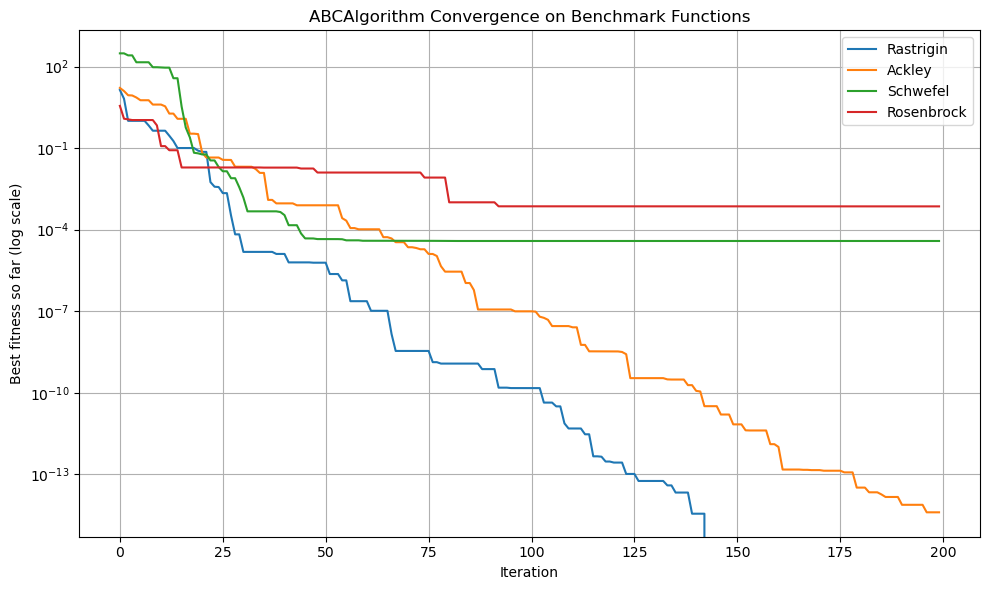

In [10]:
from ABCAlgorithm import ArtificialBeeColony

if __name__ == "__main__":
    def rastrigin(x: np.ndarray) -> float:
        x = np.asarray(x, dtype=float)
        n = x.size
        return float(10.0 * n + np.sum(x**2 - 10.0 * np.cos(2.0 * np.pi * x)))

    def ackley(x: np.ndarray) -> float:
        x = np.asarray(x, dtype=float)
        n = x.size
        sum_sq = np.sum(x**2)
        sum_cos = np.sum(np.cos(2.0 * np.pi * x))
        term1 = -20.0 * np.exp(-0.2 * np.sqrt(sum_sq / n))
        term2 = -np.exp(sum_cos / n)
        return float(term1 + term2 + 20.0 + np.e)

    def schwefel(x: np.ndarray) -> float:
        x = np.asarray(x, dtype=float)
        n = x.size
        return float(418.9829 * n - np.sum(x * np.sin(np.sqrt(np.abs(x)))))

    def rosenbrock(x: np.ndarray) -> float:
        x = np.asarray(x, dtype=float)
        return float(np.sum(100.0 * (x[1:] - x[:-1] ** 2) ** 2 + (1.0 - x[:-1]) ** 2))

    def compute_step_size(bounds, scale=0.05):
        bounds_arr = np.asarray(bounds, dtype=float)
        widths = bounds_arr[:, 1] - bounds_arr[:, 0]
        return scale * float(np.mean(widths))

    def benchmark_functions() -> None:
        dimension = 3

        test_cases = [
            ("Rastrigin", rastrigin, [(-5.12, 5.12)] * dimension),
            ("Ackley", ackley, [(-32.768, 32.768)] * dimension),
            ("Schwefel", schwefel, [(-500.0, 500.0)] * dimension),
            ("Rosenbrock", rosenbrock, [(-2.048, 2.048)] * dimension),
        ]

        histories = {}

        for name, func, bounds in test_cases:
            step_size = compute_step_size(bounds, scale=0.05)

            optimizer = ArtificialBeeColony(
                objective_function=func,
                num_food_sources=60,
                num_dimensions=3,
                max_iterations=200,
                bounds=bounds,
                limit=(60 * 3) // 2 
            )

            best_position, best_fitness = optimizer.run(max_iterations=200)
            histories[name] = optimizer.history

            print(f"\n{name} benchmark")
            print("-" * (len(name) + 10))
            print("Step size    :", step_size)
            print("Best fitness :", best_fitness)
            print("Best position:", best_position)

        plt.figure(figsize=(10, 6))

        for name, history in histories.items():
            plt.plot(history, label=name)

        plt.yscale("log")
        plt.xlabel("Iteration")
        plt.ylabel("Best fitness so far (log scale)")
        plt.title("ABCAlgorithm Convergence on Benchmark Functions")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig("abc_benchmark.png", dpi=200)
        plt.show()

    benchmark_functions()


Rastrigin benchmark
-------------------
Step size    : 0.512
Best fitness : 0.9949590570932898
Best position: [-2.66666525e-10  9.94958636e-01 -3.21768287e-09]

Ackley benchmark
----------------
Step size    : 3.2768
Best fitness : 5.3734794391857577e-14
Best position: [-1.92447275e-14 -1.83443734e-15 -1.24655697e-14]

Schwefel benchmark
------------------
Step size    : 50.0
Best fitness : 3.818269851763034e-05
Best position: [420.96874639 420.9687465  420.9687464 ]

Rosenbrock benchmark
--------------------
Step size    : 0.2048
Best fitness : 9.836830244871607e-05
Best position: [0.99554135 0.99115884 0.9824037 ]


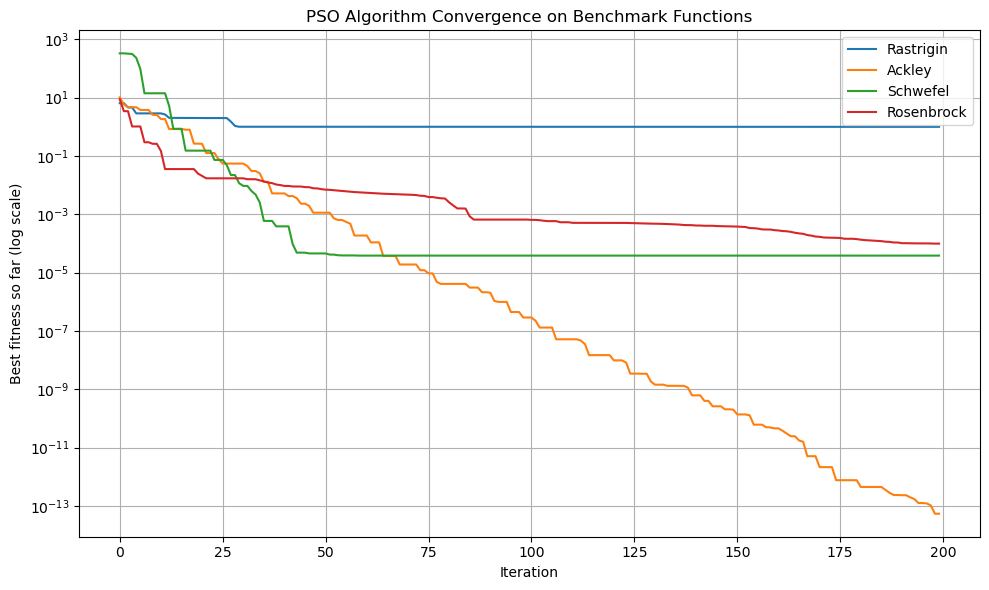

In [7]:
from PSOAlgorithm import Swarm


if __name__ == "__main__":
    def rastrigin(x: np.ndarray) -> float:
        x = np.asarray(x, dtype=float)
        n = x.size
        return float(10.0 * n + np.sum(x**2 - 10.0 * np.cos(2.0 * np.pi * x)))

    def ackley(x: np.ndarray) -> float:
        x = np.asarray(x, dtype=float)
        n = x.size
        sum_sq = np.sum(x**2)
        sum_cos = np.sum(np.cos(2.0 * np.pi * x))
        term1 = -20.0 * np.exp(-0.2 * np.sqrt(sum_sq / n))
        term2 = -np.exp(sum_cos / n)
        return float(term1 + term2 + 20.0 + np.e)

    def schwefel(x: np.ndarray) -> float:
        x = np.asarray(x, dtype=float)
        n = x.size
        return float(418.9829 * n - np.sum(x * np.sin(np.sqrt(np.abs(x)))))

    def rosenbrock(x: np.ndarray) -> float:
        x = np.asarray(x, dtype=float)
        return float(np.sum(100.0 * (x[1:] - x[:-1] ** 2) ** 2 + (1.0 - x[:-1]) ** 2))

    def compute_step_size(bounds, scale=0.05):
        bounds_arr = np.asarray(bounds, dtype=float)
        widths = bounds_arr[:, 1] - bounds_arr[:, 0]
        return scale * float(np.mean(widths))

    def benchmark_functions() -> None:
        dimension = 3

        test_cases = [
            ("Rastrigin", rastrigin, [(-5.12, 5.12)] * dimension),
            ("Ackley", ackley, [(-32.768, 32.768)] * dimension),
            ("Schwefel", schwefel, [(-500.0, 500.0)] * dimension),
            ("Rosenbrock", rosenbrock, [(-2.048, 2.048)] * dimension),
        ]

        histories = {}

        for name, func, bounds in test_cases:
            step_size = compute_step_size(bounds, scale=0.05)

            optimizer = optimizer = Swarm( num_particles=60, dim=3, bounds=bounds, func_name=func.__name__)

            best_position, best_fitness = optimizer.run(steps=200)
            histories[name] = optimizer.history

            print(f"\n{name} benchmark")
            print("-" * (len(name) + 10))
            print("Step size    :", step_size)
            print("Best fitness :", best_fitness)
            print("Best position:", best_position)

        plt.figure(figsize=(10, 6))

        for name, history in histories.items():
            plt.plot(history, label=name)

        plt.yscale("log")
        plt.xlabel("Iteration")
        plt.ylabel("Best fitness so far (log scale)")
        plt.title("PSO Algorithm Convergence on Benchmark Functions")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig("PSO_benchmark.png", dpi=200)
        plt.show()

    benchmark_functions()

# Additional Experimentations

## Hyperparameter Optimization Test

The developed algorithm is stochastic and has a few parameters to adjust that can influence the result of the algorithm.
Below is a randomized grid search setup. It samples parameter combinations, runs multiple seeds on the 4 benchmark functions, and ranks configurations by mean normalized score.

We noticed that changing weights can have significance on the performance of the algorithm. Instrestingly, Overreliance on the moisture gradient results in bad performance. Weighing in the other factors does seem to benefit the algorithm.

In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple, Any, Sequence
import csv
import json
import math
import random
import numpy as np


# ------------------------------------------------------------
# Benchmark functions
# ------------------------------------------------------------

def rastrigin(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    n = x.size
    return 10.0 * n + np.sum(x * x - 10.0 * np.cos(2.0 * np.pi * x))


def ackley(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    n = x.size
    s1 = np.sum(x * x)
    s2 = np.sum(np.cos(2.0 * np.pi * x))
    return (
        -20.0 * np.exp(-0.2 * np.sqrt(s1 / n))
        - np.exp(s2 / n)
        + 20.0
        + math.e
    )


def schwefel(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    n = x.size
    return 418.9829 * n - np.sum(x * np.sin(np.sqrt(np.abs(x))))


def rosenbrock(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    return np.sum(100.0 * (x[1:] - x[:-1] ** 2) ** 2 + (1.0 - x[:-1]) ** 2)


# ------------------------------------------------------------
# Benchmark problem definitions
# ------------------------------------------------------------

@dataclass
class BenchmarkProblem:
    name: str
    func: Callable[[np.ndarray], float]
    bounds: Sequence[Tuple[float, float]]
    optimum: float = 0.0


def make_problems(dimension: int = 3) -> List[BenchmarkProblem]:
    return [
        BenchmarkProblem("Rastrigin", rastrigin, [(-5.12, 5.12)] * dimension, 0.0),
        BenchmarkProblem("Ackley", ackley, [(-32.768, 32.768)] * dimension, 0.0),
        BenchmarkProblem("Schwefel", schwefel, [(-500.0, 500.0)] * dimension, 0.0),
        BenchmarkProblem("Rosenbrock", rosenbrock, [(-5.0, 10.0)] * dimension, 0.0),
    ]


# ------------------------------------------------------------
# Utilities
# ------------------------------------------------------------

def sample_param_config(
    rng: random.Random,
    search_space: Dict[str, Sequence[Any]],
) -> Dict[str, Any]:
    return {k: rng.choice(list(v)) for k, v in search_space.items()}


def stable_normalized_score(
    value: float,
    optimum: float = 0.0,
    eps: float = 1e-12,
) -> float:
    return abs(value - optimum) / max(abs(optimum), 1.0, eps)


def mean_std(values: Sequence[float]) -> Tuple[float, float]:
    arr = np.asarray(values, dtype=float)
    return float(np.mean(arr)), float(np.std(arr))


def serialize_value(v: Any) -> Any:
    if isinstance(v, np.ndarray):
        return v.tolist()
    if isinstance(v, tuple):
        return list(v)
    return v


# ------------------------------------------------------------
# Core evaluation
# ------------------------------------------------------------

def evaluate_config(
    config: Dict[str, Any],
    problems: Sequence[BenchmarkProblem],
    seeds: Sequence[int],
    max_iterations: int = 1200,
) -> Dict[str, Any]:
    """
    Requires PlantAlgorithm to already be defined/imported.
    """
    per_problem: Dict[str, Dict[str, Any]] = {}
    aggregate_scores: List[float] = []

    for problem in problems:
        fitnesses: List[float] = []
        positions: List[np.ndarray] = []

        for seed in seeds:
            algo = PlantAlgorithm(
                objective_function=problem.func,
                bounds=problem.bounds,
                max_root_count=config["max_root_count"],
                initial_energy=config["initial_energy"],
                step_size=config["step_size"],
                step_cost=config["step_cost"],
                splitting_threshold=config["splitting_threshold"],
                max_children=config["max_children"],
                alpha=config["alpha"],
                deposit_scale=config["deposit_scale"],
                depletion_scale=config["depletion_scale"],
                weights=config["weights"],
                repulsion_radius=config["repulsion_radius"],
                gravity_vector=np.array(config["gravity_vector"], dtype=float),
                personal_best_weight=config["personal_best_weight"],
                moisture_sigma=config["moisture_sigma"],
                moisture_base=config["moisture_base"],
                evaporation_rate=config["evaporation_rate"],
                split_ratio=config["split_ratio"],
                child_offset=config["child_offset"],
                initial_root_count=config["initial_root_count"],
                seed=seed,
            )

            best_pos, best_fit = algo.run(max_iterations=max_iterations)
            fitnesses.append(float(best_fit))
            positions.append(best_pos)

        mean_fit, std_fit = mean_std(fitnesses)
        best_run_idx = int(np.argmin(fitnesses))
        best_fit = float(fitnesses[best_run_idx])
        best_pos = positions[best_run_idx]

        score = stable_normalized_score(mean_fit, optimum=problem.optimum)
        aggregate_scores.append(score)

        per_problem[problem.name] = {
            "mean_fitness": mean_fit,
            "std_fitness": std_fit,
            "best_fitness": best_fit,
            "best_position": best_pos.tolist(),
            "all_fitnesses": [float(x) for x in fitnesses],
            "score": score,
        }

    overall_score = float(np.mean(aggregate_scores))

    return {
        "config": {k: serialize_value(v) for k, v in config.items()},
        "overall_score": overall_score,
        "per_problem": per_problem,
    }


# ------------------------------------------------------------
# Logging
# ------------------------------------------------------------

def flatten_result_for_csv(result: Dict[str, Any]) -> Dict[str, Any]:
    row: Dict[str, Any] = {}

    row["overall_score"] = result["overall_score"]

    for k, v in result["config"].items():
        if isinstance(v, (list, dict)):
            row[f"param_{k}"] = json.dumps(v)
        else:
            row[f"param_{k}"] = v

    for problem_name, metrics in result["per_problem"].items():
        prefix = problem_name.lower()
        row[f"{prefix}_mean_fitness"] = metrics["mean_fitness"]
        row[f"{prefix}_std_fitness"] = metrics["std_fitness"]
        row[f"{prefix}_best_fitness"] = metrics["best_fitness"]
        row[f"{prefix}_best_position"] = json.dumps(metrics["best_position"])
        row[f"{prefix}_all_fitnesses"] = json.dumps(metrics["all_fitnesses"])
        row[f"{prefix}_score"] = metrics["score"]

    return row


def write_results_csv(results: List[Dict[str, Any]], filepath: str) -> None:
    rows = [flatten_result_for_csv(r) for r in results]
    if not rows:
        return

    fieldnames: List[str] = []
    seen = set()
    for row in rows:
        for key in row.keys():
            if key not in seen:
                seen.add(key)
                fieldnames.append(key)

    with open(filepath, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def write_best_config_json(result: Dict[str, Any], filepath: str) -> None:
    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2)


# ------------------------------------------------------------
# Random search
# ------------------------------------------------------------

def random_grid_search_with_logs(
    search_space: Dict[str, Sequence[Any]],
    problems: Sequence[BenchmarkProblem],
    n_samples: int = 40,
    seeds_per_config: Sequence[int] = (0, 1, 2),
    max_iterations: int = 1200,
    random_state: int = 123,
    top_k: int = 10,
    all_results_csv: str = "all_results.csv",
    top_results_csv: str = "top_results.csv",
    best_config_json: str = "best_config.json",
) -> List[Dict[str, Any]]:
    rng = random.Random(random_state)
    seen = set()
    all_results: List[Dict[str, Any]] = []

    max_unique = 1
    for values in search_space.values():
        max_unique *= len(values)

    actual_samples = min(n_samples, max_unique)

    while len(all_results) < actual_samples:
        config = sample_param_config(rng, search_space)

        key = tuple(
            (k, tuple(v) if isinstance(v, (list, tuple, np.ndarray)) else v)
            for k, v in sorted(config.items(), key=lambda item: item[0])
        )
        if key in seen:
            continue
        seen.add(key)

        result = evaluate_config(
            config=config,
            problems=problems,
            seeds=seeds_per_config,
            max_iterations=max_iterations,
        )
        all_results.append(result)

        write_results_csv(all_results, all_results_csv)

        print(
            f"[{len(all_results)}/{actual_samples}] "
            f"score={result['overall_score']:.6f}"
        )

    all_results.sort(key=lambda r: r["overall_score"])
    top_results = all_results[:top_k]

    write_results_csv(all_results, all_results_csv)
    write_results_csv(top_results, top_results_csv)
    write_best_config_json(top_results[0], best_config_json)

    return top_results


# ------------------------------------------------------------
# Search space
# ------------------------------------------------------------

def make_search_space(dimension: int = 3) -> Dict[str, Sequence[Any]]:
    zero_gravity = tuple([0.0] * dimension)

    return {
        "max_root_count": [40, 60, 80],
        "initial_energy": [4.0, 6.0, 8.0, 10.0],
        "step_size": [0.04, 0.08, 0.12, 0.18, 0.25],
        "step_cost": [0.01, 0.02, 0.03, 0.05],
        "splitting_threshold": [4.0, 5.0, 6.0, 8.0],
        "max_children": [1, 2, 3],
        "alpha": [2.0, 4.0, 8.0, 12.0],
        "deposit_scale": [0.5, 1.0, 2.0, 4.0, 8.0],
        "depletion_scale": [0.005, 0.01, 0.03, 0.05, 0.08],
        "weights": [
            (1.0, 0.0, 0.10, 0.20),
            (1.4, 0.0, 0.15, 0.30),
            (1.8, 0.0, 0.25, 0.45),
            (2.2, 0.0, 0.10, 0.60),
            (2.5, 0.0, 0.05, 0.80),
        ],
        "repulsion_radius": [0.4, 0.8, 1.2, 1.8],
        "gravity_vector": [zero_gravity],
        "personal_best_weight": [0.4, 0.8, 1.2, 1.8, 2.5],
        "moisture_sigma": [0.4, 0.7, 0.9, 1.2, 1.8],
        "moisture_base": [0.001, 0.01, 0.05, 0.1],
        "evaporation_rate": [0.001, 0.005, 0.01, 0.03, 0.05],
        "split_ratio": [0.25, 0.45, 0.60],
        "child_offset": [0.02, 0.06, 0.12, 0.20],
        "initial_root_count": [4, 8, 12],
    }


# ------------------------------------------------------------
# Main
# ------------------------------------------------------------

if __name__ == "__main__":
    # from your_algorithm_file import PlantAlgorithm

    DIMENSION = 3
    MAX_ITERATIONS = 100
    N_SAMPLES = 10
    SEEDS_PER_CONFIG = [0, 1, 2, 3, 4]

    problems = make_problems(dimension=DIMENSION)
    search_space = make_search_space(dimension=DIMENSION)

    top_results = random_grid_search_with_logs(
        search_space=search_space,
        problems=problems,
        n_samples=N_SAMPLES,
        seeds_per_config=SEEDS_PER_CONFIG,
        max_iterations=MAX_ITERATIONS,
        random_state=42,
        top_k=5,
        all_results_csv="all_results.csv",
        top_results_csv="top_results.csv",
        best_config_json="best_config.json",
    )

    print("\nTop 5 configurations:")
    for i, result in enumerate(top_results, start=1):
        print(f"Rank #{i}: score={result['overall_score']:.6f}")
        print(result["config"])

### Expolation vs Exploitation
A specific analysis of how the algorithm avoids local optima (diversification) and how it homes in on the global best (intensification).

### The "Anti-Derivative" Proof
A section explicitly stating how this algorithm differs fundamentally from PSO, ACO, and GA in its logic (e.g., different neighborhood structure or movement physics).

### Benchmarking & Analysis